# PCA + UMAP — Dimensionsreduktion & Klassificering

## Varför dimensionsreduktion?
Vi har 9 features. Det är inte mycket — men:
- I EDA såg vi att x, y, z korrelerar 0.99 med varandra (multikollinearitet)
- Logistisk Regression visade att y, carat, x, z alla har stora koefficienter
  → de delar förklaringskraft sinsemellan
- Det är **svårt att visualisera 9D-data** — vi kan bara plotta 2 eller 3 axlar i taget

Två tekniker för att komprimera datan:

| | PCA | UMAP |
|---|---|---|
| **Typ** | Linjär | Icke-linjär |
| **Mål** | Bevara varians (global struktur) | Bevara närhetsrelationer (lokal struktur) |
| **Hur** | Hittar riktningar med max varians | Bygger graf, projicerar till låg dimension |
| **Snabb?** | Ja, mycket | Nej, betydligt långsammare |
| **Tolkbar?** | Ja — komponenter är linjärkombinationer | Nej — magisk svart låda |
| **Bäst för** | Linjära samband, tabelldata | Komplexa kluster, manifolds |

## Vad undersöker vi i denna notebook?

**Del 1 — PCA**
1. Köra PCA på alla 9 features → titta på explained variance
2. Visualisera klasserna i PCA-2D och PCA-3D
3. Använda PCA som **förbehandlingssteg** före LogReg och KNN
4. Mäta om klassificeringen blir bättre eller sämre

**Del 2 — UMAP**
5. Köra UMAP → visualisera klasserna i UMAP-2D
6. Använda UMAP som förbehandlingssteg före LogReg och KNN
7. Jämföra med PCA-resultaten

**Del 3 — Sammanfattning**
8. Vilken metod fungerade bäst? Varför?

## Hypotes
- **PCA-2D bör räcka** för att visualisera klasserna eftersom carat
  är så dominant — en huvudkomponent fångar troligen 70%+ av variansen
- **PCA före LogReg** kanske presterar något sämre än rå LogReg —
  vi förlorar information men vinner tolkbarhet
- **UMAP visualisering** kan ge tydligare separation av klasser om det
  finns någon icke-linjär struktur, men på detta dataset är vi osäkra
- **UMAP före KNN** kan teoretiskt hjälpa eftersom UMAP komprimerar
  närhetsrelationer — men det är en räddningsplan för svårsepererad data,
  och vår data är redan lättseparerad

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────────
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (behövs för 3D-plot)

import umap

# Lägg till projektets rot i sökvägen
sys.path.append(os.path.abspath(".."))

from src.data_processing import encode_categories, create_price_label, split_and_scale
from src.evaluation import print_classification_report, plot_confusion_matrix, plot_roc_curve

# ── Inställningar ──────────────────────────────────────────────────────────────
CLEAN_DATA = "../data/diamonds_clean.csv"
OUTPUT_DIR = "../outputs/models/"

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

print("✅ Imports och konfiguration klar!")
print(f"   Datafil  : {CLEAN_DATA}")
print(f"   Output   : {OUTPUT_DIR}")

✅ Imports och konfiguration klar!
   Datafil  : ../data/diamonds_clean.csv
   Output   : ../outputs/models/


## 1. Ladda & förbered data

Samma pipeline som i föregående notebooks — vi använder `price_label`
(binärt) som target eftersom vi vill utvärdera dimensionsreduktion
för klassificering.

In [2]:
# ── Ladda rensat dataset ───────────────────────────────────────────────────────
df = pd.read_csv(CLEAN_DATA)
print(f"✅ Data laddad: {df.shape[0]:,} rader × {df.shape[1]} kolumner")

# ── Enkoda kategoriska variabler ───────────────────────────────────────────────
df = encode_categories(df)

# ── Skapa binär prislabel ──────────────────────────────────────────────────────
df = create_price_label(df)

# ── Dela upp i träning och test ────────────────────────────────────────────────
X_train, X_test, y_train, y_test, features, scaler = split_and_scale(df)

print(f"\nFeatures: {len(features)} st")

✅ Data laddad: 53,772 rader × 10 kolumner
✅ Kategorier enkodade: cut, color, clarity → numeriska värden
✅ Prisgräns satt till $2,401 (median)
   Dyra diamanter (1): 26,874
   Billiga diamanter (0): 26,898
✅ Datasplit: 43,017 träning / 10,755 test
   Features: ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z']

Features: 9 st


## 2. PCA — Hur mycket varians fångar varje komponent?

PCA hittar riktningar i feature-rymden där datan varierar mest.
Den **första komponenten (PC1)** är riktningen med mest varians,
**PC2** är ortogonal mot PC1 och har näst mest varians, osv.

**Explained variance ratio** säger hur stor andel av total varians
varje komponent fångar. En **scree plot** visar det visuellt.

**Tumregler:**
- Om PC1 + PC2 fångar >80% → 2D-visualisering är representativ
- "Knäböj" i kurvan → så många komponenter behövs ungefär
- Kumulativ varians >95% → bra approximation av originaldatan

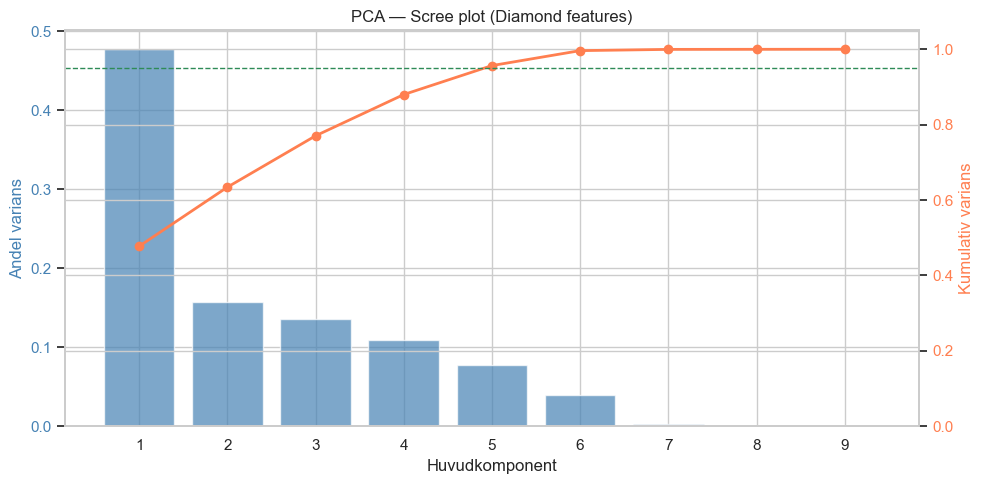


📊 Explained Variance per komponent:
Komp.   Varians     Kumulativ   
────────────────────────────────
PC1     0.4773      0.4773      
PC2     0.1567      0.6340      
PC3     0.1363      0.7703      
PC4     0.1095      0.8798      
PC5     0.0769      0.9567      
PC6     0.0397      0.9963      
PC7     0.0033      0.9997      
PC8     0.0002      0.9999      
PC9     0.0001      1.0000      


In [3]:
# ── PCA på all data (för att se explained variance) ───────────────────────────
pca_full = PCA(n_components=len(features), random_state=42)
pca_full.fit(X_train)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

# ── Scree plot (varje komponent + kumulativ) ──────────────────────────────────
fig, ax1 = plt.subplots(figsize=(10, 5))

components = range(1, len(features) + 1)
ax1.bar(components, explained, color="steelblue", alpha=0.7, label="Varians per komponent")
ax1.set_xlabel("Huvudkomponent")
ax1.set_ylabel("Andel varians", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.set_xticks(components)

ax2 = ax1.twinx()
ax2.plot(components, cumulative, marker="o", color="coral", lw=2, label="Kumulativ varians")
ax2.axhline(0.95, color="seagreen", linestyle="--", lw=1, label="95% tröskel")
ax2.set_ylabel("Kumulativ varians", color="coral")
ax2.tick_params(axis="y", labelcolor="coral")
ax2.set_ylim(0, 1.05)

plt.title("PCA — Scree plot (Diamond features)")
fig.tight_layout()
plt.savefig(f"{OUTPUT_DIR}pca_01_scree.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Tabell ─────────────────────────────────────────────────────────────────────
print("\n📊 Explained Variance per komponent:")
print(f"{'Komp.':<8}{'Varians':<12}{'Kumulativ':<12}")
print("─" * 32)
for i, (var, cum) in enumerate(zip(explained, cumulative), 1):
    print(f"PC{i:<6}{var:<12.4f}{cum:<12.4f}")

### Vad ser vi? — Scree plot

**Explained variance per komponent:**

| Komponent | Varians | Kumulativ | Tolkning |
|---|---|---|---|
| PC1 | 47.7% | 47.7% | Dominerar — fångar storleksdimensionen (carat, x, y, z) |
| PC2 | 15.7% | 63.4% | Andra dimensionen — troligen kvalitet (color, clarity, cut) |
| PC3 | 13.6% | 77.0% | Mer kvalitet/proportion |
| PC4 | 11.0% | 88.0% | Marginell tillförsel |
| PC5 | 7.7% | **95.7%** | ✅ Här passerar vi 95%-tröskeln |
| PC6 | 4.0% | 99.6% | Nästan inget tillskott |
| PC7–PC9 | <0.5% | 100% | Numeriskt brus — ingen meningsfull information |

**Insikter:**
- **PC1 är inte så dominant som vi gissade** — bara 47.7%. Det betyder
  att flera dimensioner krävs för att fånga datans struktur, även om
  carat är starkt korrelerad med flera features
- **5 komponenter räcker** för att fånga 95% av variansen → vi kan
  reducera från 9 till 5 features med minimal informationsförlust
- **Tydligt knäböj efter PC4** — kurvan planar ut. Det är signalen
  som scree-metoden bygger på
- **PC7–PC9 (sammanlagt <0.5%)** = redundans från x/y/z och cut/color/clarity
  som korrelerar starkt sinsemellan

**Sammanlagd kumulativ varians:**
- 2D (PC1 + PC2): **63.4%** — anständigt för visualisering, men inte komplett
- 3D (PC1 + PC2 + PC3): **77.0%** — bra för visualisering
- 5D: 95.7% — produktionsklart för modellering

**Konsekvens:**
2D-projektionen kommer att visa klasserna men med viss överlappning —
36.6% av variansen "komprimeras bort". Det är OK för visualisering,
inte ideal för klassificering.

## 3. PCA — Visualisera klasserna i 2D och 3D

Nu projicerar vi datan ned till 2D och 3D och färgar punkterna efter
klass (Billig vs Dyr). Om klasserna **separeras visuellt** så vet vi
att en linjär modell kan lyckas — det är vad vi förväntar oss baserat
på Logistisk Regression-resultaten.

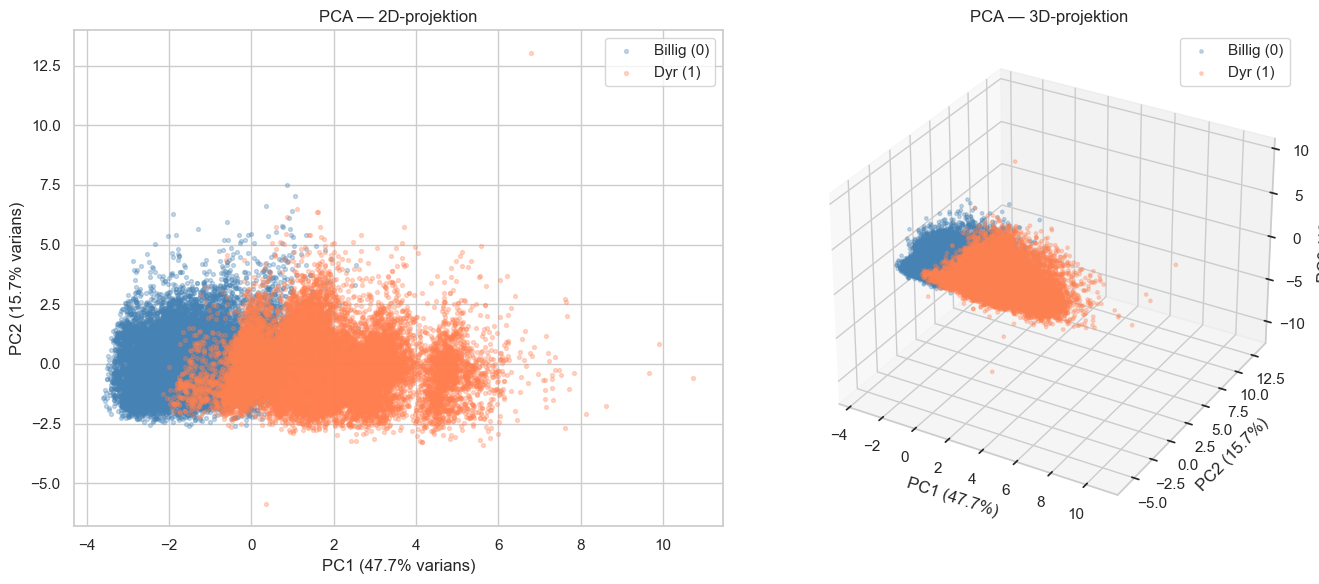


2D total varians: 63.4%
3D total varians: 77.0%


In [4]:
# ── PCA till 2D och 3D för visualisering ──────────────────────────────────────
pca_2d = PCA(n_components=2, random_state=42)
X_train_2d = pca_2d.fit_transform(X_train)

pca_3d = PCA(n_components=3, random_state=42)
X_train_3d = pca_3d.fit_transform(X_train)

# ── Två-panelers plot: 2D + 3D ────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 6))

# Vänster: 2D scatter
ax1 = fig.add_subplot(1, 2, 1)
y_train_arr = np.asarray(y_train)
för_billig = y_train_arr == 0
för_dyr    = y_train_arr == 1

ax1.scatter(X_train_2d[för_billig, 0], X_train_2d[för_billig, 1],
            alpha=0.3, s=8, color="steelblue", label="Billig (0)")
ax1.scatter(X_train_2d[för_dyr, 0], X_train_2d[för_dyr, 1],
            alpha=0.3, s=8, color="coral", label="Dyr (1)")
ax1.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% varians)")
ax1.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% varians)")
ax1.set_title("PCA — 2D-projektion")
ax1.legend()

# Höger: 3D scatter
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.scatter(X_train_3d[för_billig, 0], X_train_3d[för_billig, 1], X_train_3d[för_billig, 2],
            alpha=0.3, s=6, color="steelblue", label="Billig (0)")
ax2.scatter(X_train_3d[för_dyr, 0], X_train_3d[för_dyr, 1], X_train_3d[för_dyr, 2],
            alpha=0.3, s=6, color="coral", label="Dyr (1)")
ax2.set_xlabel(f"PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)")
ax2.set_ylabel(f"PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)")
ax2.set_zlabel(f"PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)")
ax2.set_title("PCA — 3D-projektion")
ax2.legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}pca_02_2d_3d.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n2D total varians: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%")
print(f"3D total varians: {pca_3d.explained_variance_ratio_.sum()*100:.1f}%")

### Vad ser vi? — PCA-projektion av klasserna

**PCA-2D:**
- **Tydlig separation längs PC1:** billiga diamanter (blå) ligger till
  vänster (PC1 ≈ −4 till 2), dyra diamanter (orange) till höger
  (PC1 ≈ 0 till 10)
- **Klassgränsen är ungefär PC1 ≈ 1** — runt nollstrecket finns en
  smal överlappszon
- **PC2 separerar inte klasserna** — billiga och dyra är båda spridda
  vertikalt över hela PC2-axeln (≈ −5 till 12). PC2 fångar något annat
  än prisrelaterad information
- **Outlier upptill** (PC2 ≈ 12) — troligen en diamant med ovanligt djup
  eller table-värde

**Tolkning av PC1:**
Eftersom PC1 fångar 47.7% av variansen och separerar klasserna så väl,
kan vi anta att PC1 ≈ "storlek/karat-axel". Det stämmer med EDA — carat
är den absolut viktigaste prediktorn av pris.

**PCA-3D:**
- **PC3 hjälper inte mycket** — klasserna ligger i samma "skiva" i
  rymden, oavsett PC3-värde. Klusterformen liknar en utdragen elips
  som sträcker sig längs PC1
- 3D-projektionen ser ungefär ut som 2D men med extra spridning på djupet
- Det är en bekräftelse på att dimensionsreduktion till 2D är meningsfullt
  här — den extra dimensionen ger marginell information

**Sammanfattning:**
- Klasserna separeras nästan helt längs PC1 → en linjär klassificerare
  (LogReg) kan dra ett bra beslutsplan
- Detta förklarar varför LogReg redan presterar 98% — datan är linjärt
  separerbar i en rymd som PCA enkelt kan hitta

## 4. PCA som förbehandlare — Klassificering på reducerad data

Nu går vi från visualisering till **modellering**. Vi tränar Logistisk
Regression och KNN på data som först har reducerats med PCA.

**Vad vi testar:**
- PCA → LogReg (med 2, 3, 5 komponenter)
- PCA → KNN (med samma antal komponenter)

**Förväntning:**
- 2 komponenter: information tappas (63.4% varians) → sämre accuracy
- 5 komponenter: nästan all information bevaras (95.7%) → nästan
  identisk accuracy som rå modell
- KNN bör gynnas mer av PCA än LogReg eftersom KNN är skalkänslig
  och dimensionsreduktion minskar "curse of dimensionality"

In [5]:
# ── PCA + Klassificerare över olika antal komponenter ──────────────────────────
# Använder bästa parametrarna från notebook 03 för KNN
KNN_BEST_PARAMS = {"n_neighbors": 17, "weights": "distance", "metric": "manhattan"}

n_components_list = [2, 3, 5]

results_pca = []

for n in n_components_list:
    # PCA-transformation
    pca = PCA(n_components=n, random_state=42)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca  = pca.transform(X_test)

    # ── Logistisk Regression ──────────────────────────────────────────────────
    logreg = LogisticRegression(max_iter=1000, random_state=42)
    logreg.fit(X_train_pca, y_train)
    y_pred_lr = logreg.predict(X_test_pca)
    y_prob_lr = np.asarray(logreg.predict_proba(X_test_pca))[:, 1]

    acc_lr = accuracy_score(y_test, y_pred_lr)
    auc_lr = roc_auc_score(y_test, y_prob_lr)

    # ── KNN ───────────────────────────────────────────────────────────────────
    knn = KNeighborsClassifier(**KNN_BEST_PARAMS)
    knn.fit(X_train_pca, y_train)
    y_pred_knn = knn.predict(X_test_pca)
    y_prob_knn = np.asarray(knn.predict_proba(X_test_pca))[:, 1]

    acc_knn = accuracy_score(y_test, y_pred_knn)
    auc_knn = roc_auc_score(y_test, y_prob_knn)

    results_pca.append({
        "n_components": n,
        "var_kumulativ": float(pca.explained_variance_ratio_.sum()),
        "logreg_acc":    acc_lr,
        "logreg_auc":    auc_lr,
        "knn_acc":       acc_knn,
        "knn_auc":       auc_knn,
    })

    print(f"PCA n={n} ({pca.explained_variance_ratio_.sum()*100:.1f}% varians):")
    print(f"   LogReg : acc={acc_lr:.4f}, AUC={auc_lr:.3f}")
    print(f"   KNN    : acc={acc_knn:.4f}, AUC={auc_knn:.3f}\n")

# ── Tabell ─────────────────────────────────────────────────────────────────────
results_df = pd.DataFrame(results_pca)
print("\n📊 Sammanställning — PCA + Klassificerare:")
print(results_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

PCA n=2 (63.4% varians):
   LogReg : acc=0.9223, AUC=0.982
   KNN    : acc=0.9389, AUC=0.984

PCA n=3 (77.0% varians):
   LogReg : acc=0.9277, AUC=0.984
   KNN    : acc=0.9415, AUC=0.986

PCA n=5 (95.7% varians):
   LogReg : acc=0.9747, AUC=0.997
   KNN    : acc=0.9739, AUC=0.997


📊 Sammanställning — PCA + Klassificerare:
 n_components  var_kumulativ  logreg_acc  logreg_auc  knn_acc  knn_auc
            2         0.6340      0.9223      0.9823   0.9389   0.9837
            3         0.7703      0.9277      0.9838   0.9415   0.9859
            5         0.9567      0.9747      0.9973   0.9739   0.9965


## 5. Visualisera PCA-baserade beslutsgränser

För att verkligen förstå vad PCA + klassificerare gör tittar vi på
**beslutsgränsen** i PCA-2D-rymden. Det är linjen (eller kurvan) där
modellen är osäker — där sannolikheten är 50%.

- **LogReg** ger en rak linje (linjär modell)
- **KNN** ger en böljig gräns (lokal modell, följer datapunkterna)

Detta visualiserar varför LogReg och KNN beter sig olika.

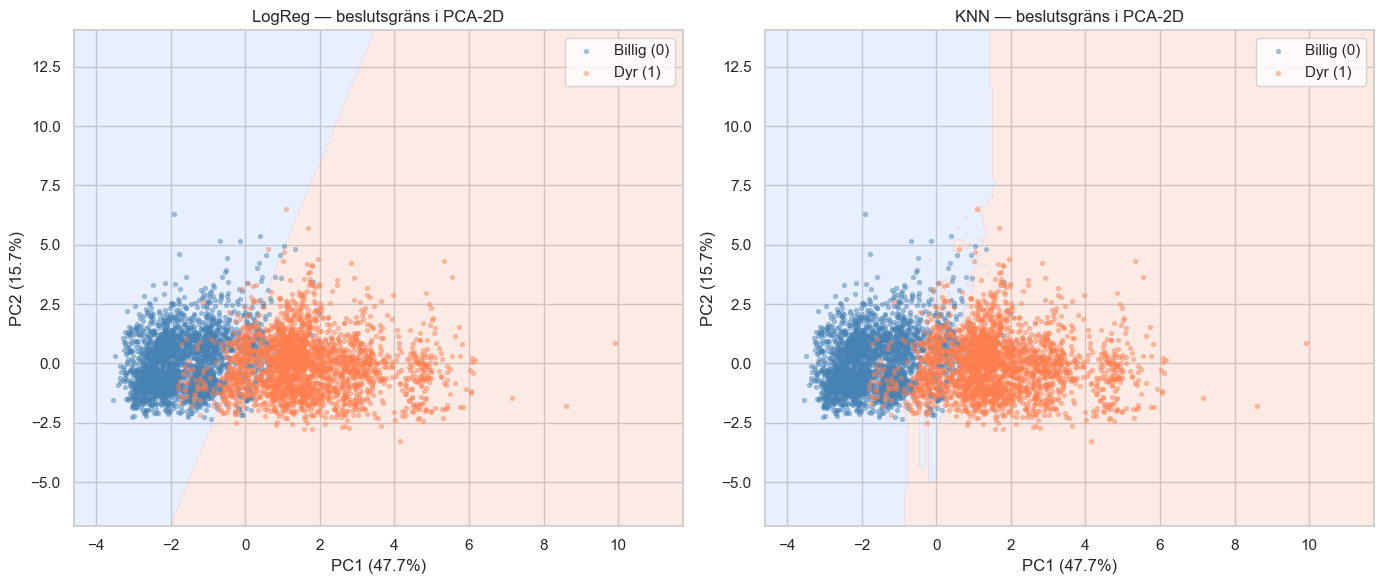

In [6]:
# ── Tränar 2D-modellerna för visualisering ────────────────────────────────────
pca_2d_vis = PCA(n_components=2, random_state=42)
X_train_2d = pca_2d_vis.fit_transform(X_train)
X_test_2d  = pca_2d_vis.transform(X_test)

logreg_2d = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_2d, y_train)
knn_2d    = KNeighborsClassifier(**KNN_BEST_PARAMS).fit(X_train_2d, y_train)

# ── Skapa rutnät för beslutsgräns ─────────────────────────────────────────────
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1

# Använd grovt rutnät för KNN (den är långsam)
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

Z_lr  = logreg_2d.predict(grid).reshape(xx.shape)
Z_knn = knn_2d.predict(grid).reshape(xx.shape)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Använd subsampling för scatter — 5,000 punkter räcker för visualisering
np.random.seed(42)
idx = np.random.choice(len(X_train_2d), size=5000, replace=False)
y_sub = np.asarray(y_train)[idx]

for ax, Z, title in [
    (axes[0], Z_lr,  "LogReg — beslutsgräns i PCA-2D"),
    (axes[1], Z_knn, "KNN — beslutsgräns i PCA-2D"),
]:
    ax.contourf(xx, yy, Z, alpha=0.2, cmap="coolwarm", levels=1)
    ax.scatter(X_train_2d[idx][y_sub == 0, 0], X_train_2d[idx][y_sub == 0, 1],
               s=8, alpha=0.4, color="steelblue", label="Billig (0)")
    ax.scatter(X_train_2d[idx][y_sub == 1, 0], X_train_2d[idx][y_sub == 1, 1],
               s=8, alpha=0.4, color="coral", label="Dyr (1)")
    ax.set_xlabel(f"PC1 ({pca_2d_vis.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca_2d_vis.explained_variance_ratio_[1]*100:.1f}%)")
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}pca_03_decision_boundaries.png", dpi=150, bbox_inches="tight")
plt.show()